Second derivatives M:
[ 0.         -6.96428571  9.85714286 -8.46428571  0.        ]
First 10 interpolated points:
x = 0.000, y = 1.000
x = 0.020, y = 1.064
x = 0.040, y = 1.127
x = 0.060, y = 1.190
x = 0.080, y = 1.254
x = 0.101, y = 1.316
x = 0.121, y = 1.379
x = 0.141, y = 1.441
x = 0.161, y = 1.503
x = 0.181, y = 1.565


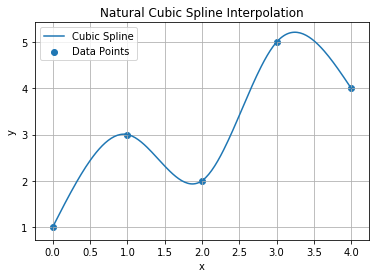

In [4]:
#references: chatgpt, asked about Tridiagonal System and Thomas Algorithm
#https://adamdjellouli.com/articles/numerical_methods/6_regression/cubic_spline_interpolation?
#https://en.wikipedia.org/wiki/Tridiagonal_matrix_algorithm?
#https://www.scribd.com/document/477298099/Cubic-Spline?
import numpy as np
import matplotlib.pyplot as plt

def natural_cubic_spline(x, y):
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)
    n = len(x)

    if n < 3:
        raise ValueError("Need at least 3 data points.")
    if np.any(np.diff(x) <= 0):
        raise ValueError("x values must be strictly increasing.")

    h = np.diff(x)

    #Tridiagonal system
    #lower diagonal
    a = np.zeros(n)
    #main diagonal
    b = np.zeros(n)
    #upper diagonal
    c = np.zeros(n)
    #right-hand side
    d = np.zeros(n)

    #Natural spline boundary conditions
    b[0] = 1
    b[-1] = 1

    for i in range(1, n - 1):
        a[i] = h[i - 1]
        b[i] = 2 * (h[i - 1] + h[i])
        c[i] = h[i]
        d[i] = 6 * ((y[i + 1] - y[i]) / h[i] - (y[i] - y[i - 1]) / h[i - 1])

    #Thomas Algorithm
    c_star = np.zeros(n)
    d_star = np.zeros(n)

    c_star[0] = c[0] / b[0]
    d_star[0] = d[0] / b[0]

    for i in range(1, n):
        denom = b[i] - a[i] * c_star[i - 1]
        c_star[i] = c[i] / denom if i < n - 1 else 0
        d_star[i] = (d[i] - a[i] * d_star[i - 1]) / denom

    M = np.zeros(n)
    M[-1] = d_star[-1]

    for i in range(n - 2, -1, -1):
        M[i] = d_star[i] - c_star[i] * M[i + 1]

    return x, y, h, M

def evaluate_spline(x, y, h, M, x_eval):
    x_eval = np.array(x_eval, dtype=float)
    y_eval = np.zeros_like(x_eval)

    for j, xv in enumerate(x_eval):
        if xv <= x[0]:
            i = 0
        elif xv >= x[-1]:
            i = len(x) - 2
        else:
            i = np.searchsorted(x, xv) - 1

        hi = h[i]
        xi, xi1 = x[i], x[i + 1]
        yi, yi1 = y[i], y[i + 1]
        Mi, Mi1 = M[i], M[i + 1]

        y_eval[j] = (
            Mi * (xi1 - xv) ** 3 / (6 * hi)
            + Mi1 * (xv - xi) ** 3 / (6 * hi)
            + (yi - Mi * hi ** 2 / 6) * (xi1 - xv) / hi
            + (yi1 - Mi1 * hi ** 2 / 6) * (xv - xi) / hi
        )

    return y_eval


#Example data points
x = [0, 1, 2, 3, 4]
y = [1, 3, 2, 5, 4]

#Build spline
x_nodes, y_nodes, h, M = natural_cubic_spline(x, y)

#Evaluate spline on many points for smooth curve
x_dense = np.linspace(min(x), max(x), 200)
y_dense = evaluate_spline(x_nodes, y_nodes, h, M, x_dense)

#Print some output
print("Second derivatives M:")
print(M)

print("First 10 interpolated points:")
for i in range(10):
    print(f"x = {x_dense[i]:.3f}, y = {y_dense[i]:.3f}")

#Plot
plt.plot(x_dense, y_dense, label="Cubic Spline")
plt.scatter(x, y, label="Data Points")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Natural Cubic Spline Interpolation")
plt.legend()
plt.grid(True)
plt.show()